In [5]:
from langchain_community.chat_models import ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("../documents/income_tax.pdf")
pages = []

async for page in loader.alazy_load():
    pages.append(page)

len(pages)
pages[35]

Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2025-01-10T10:55:01+09:00', 'moddate': '2025-01-10T10:55:01+09:00', 'source': '../documents/income_tax.pdf', 'total_pages': 133, 'page': 35, 'page_label': '36'}, page_content='법제처                                                            36                                                       국가법령정보센터\n소득세법\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다\n)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호의 금액을 12로 나눈 금액에 근속연수를 곱한 금액\n3. 삭제<2014. 12. 23.>\n[전문개정 2009. 12. 31.]\n \n           제2관 세액공제 <개정 2009. 12. 31.>\n \n제56조(배당세액공제) ① 거주자의 종합소득금액에 제17조제3항 각 호 외의 부분 단서가 적용되는 배당소득금액이 합\n산되어 있는 경우에는 같은 항 각 호 외의 부분 단서에 따라 해당 과세기간의 총수입금액에 더한 금액에 해당하는\n금액을 종합소득 산출세액에서 공제한다. <개정 2009. 12. 31.>\n② 제1항에 따른 공제를 “배당세액공제”라 한다.<개정 2009. 12. 31.>\n③ 삭제<2003. 12. 30.>\n④ 제1항을 적용할 때 배당세액공제의 대상이 되는 배당소득금액은 제14조제2항의 종합소득과세표준에 포함된 배\n당소득금액으로서 이자소득등의 종합과세기

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size= 1500,
    chunk_overlap= 100,
    separators = ["\n\n", "\n"]
)

In [9]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader

markdown_path = "../documents/income_tax.md"
loader = UnstructuredMarkdownLoader(markdown_path)
document_list = loader.load_and_split(text_splitter)

In [11]:
document_list[39]

Document(metadata={'source': '../documents/income_tax.md'}, page_content='특별소득공제에 관해서는 그 밖에 필요한 사항을 대봉정림으로 정한다.<개정 2014. 1. 1.>\n\n제53조(생재를 같이 하는 부양가족의 범위와 판단기준) 제50조에 규정된 생계를 같이 하는 부양가족의 주민등록표 상의 동거가족으로서 해당 거주자의 주소 또는 거소에 실질적으로 생계를 같이 하는 사람으로 판단한다. 단, 자치법령에 의한 경우는 그러하지 아니하다. ① 거주자 또는 동거가족(친지부모; 입양자는 제외한다)에 취하, 질병의 양, 근무 또는 신자의 형 등의 본래의 주소 또는 거소에서 실질적으로 대봉정림으로 판단되는 사유에 해당할 경우에는 제1항의 세례를 같이 하는 사람으로 본다. ② 거주자의 부양가족 중 거주자와 배우자를 포함하는 자의 직제 형태에 대해 별거하고 있는 경우에는 제51조에 불구하고 제50조에서 규정하는 생계를 같이 하는 사람으로 본다. ③ 제50조, 제51조 및 제50조의2에 따른 기준대상 배우자, 공직자는 부양자, 공적장애자는 공적장애 경로 우대에 해당하는 경우에는 차례로 밝히느냐에 관계하여 보건의 현재 상징에 따른다. 단, 자치기관 등의 견절에 의한 사람 또는 장애에 대하여 치유를 받지 또는 치료의 상황에 따라 한다.<개정 2014. 1. 1.>\n\n제54조(종합소득 공제의 범위) ① 근로자이자소득, 분리과세배당소득, 분리과세연금소득과 근로자 이외의 자만 있는 경우에 대해서는 종합소득공제를 적용하지 아니한다.<개정 2013. 1. 1.> ② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.> ③ 제80조에 따른 수익과 관련의 경우

In [14]:
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

In [16]:
from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents= document_list,
    embedding= embeddings,
    collection_name= "income_tax_collection",
    persist_directory= "./income_tax_collection",
)

In [18]:
retriever = vector_store.as_retriever(search_kwarge={"k": 3})

In [17]:
query = "연봉 5천만원 직장인의 소득세는?"

In [19]:
retriever.invoke(query)

[Document(id='a81a9baf-ddc3-4a63-b424-6e0c12f78a2e', metadata={'source': '../documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
 Document(id='a5a56404-9342-4710-9bb5-323d3711f7d6', metadata={'source': '../documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령

In [20]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [21]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

/Users/kimbro/projects/파이썬/llm_rag_application/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [22]:
def retrieve(state: AgentState) -> AgentState:
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [31]:
from langsmith import Client
from langchain_openai import ChatOpenAI

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)
llm = ChatOpenAI(model = "gpt-4o")

In [32]:
def generate(state: AgentState) -> AgentState:
    context = state['context']  # state에서 검색된 문서를 추출
    query = state['query']  # state에서 사용자의 질문을 추출
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인 생성
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

In [33]:
graph = graph_builder.compile()

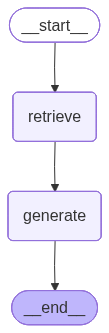

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='a81a9baf-ddc3-4a63-b424-6e0c12f78a2e', metadata={'source': '../documents/income_tax.md'}, page_content='다. 제16조제1항제10호에 따른 직장공제회초과받환급에 대해서는 기본세율 라. 그 밖의 이자소득에 대해서는 100분의 14\n\n배당소득에 대해서는 다음과 같이 추정하는 세율 가. 제7조제1항제2호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25 나. 그 밖의 배당소득에 대해서는 100분의 14\n\n원천소득당 사업소득에 대해서는 100분의 3. 단, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클래지 사용 명 중 프로스포츠단만의 계약(계약기간이 3년 이하인 경우)을 한다는 조건에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다.\n\n근로소득에 대해서는 기본세율. 단, 임금근로자의 근로소득에 대해서는 100분의 6으로 한다.\n\n공적연금소득에 대해서는 기본세율\n\n59.제210조제3조제1항제2호관련 및 다목에 따른 연금계좌 납입액에 따른 증감지급 금액을 연금수령할 연금소득세에 대해서는 다음 각 호의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n\n가. 연금소득자와 나이에 따른 단일의 세율 나이(연금수령형태) 세율 70세 미만 100분의 5 70세 이상 100분의 3\n\n스텍스트판'),
  Document(id='a5a56404-9342-4710-9bb5-323d3711f7d6', metadata={'source': '../documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여